In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler,LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.linear_model import Lasso
from sklearn.linear_model import Ridge
from sklearn.model_selection import train_test_split,RandomizedSearchCV
from sklearn.metrics import mean_squared_error,r2_score

In [6]:
df = pd.read_csv("data18.csv")
df.head()

,Soil_Type,Crop,Rainfall_mm,Temperature_Celsius,Fertiliser_Quantity,Pesticide_Quantity,Yield_tons_per_acre
0,Clay,Wheat,225.117079,19.191553,59488.380629,811.673690,1.728929
1,Sandy Loam,Wheat,315.951046,24.513009,95981.507082,574.246763,2.142011
2,Sandy Loam,Rice,444.892536,32.136555,89884.767017,657.781659,2.581379
3,Clay,Wheat,492.812499,19.984464,73514.309720,338.288175,1.515758
4,Chalky,Rice,426.559034,34.057319,107404.150948,406.520062,2.798321


In [7]:
#Encode Categorical Variables
label_encoder = {}
categorical_cols = ['Soil_Type','Crop','Fertiliser_Quantity','Pesticide_Quantity']
for col in categorical_cols:
    encoder = LabelEncoder()
    df[col] = encoder.fit_transform(df[col])
    label_encoder[col] = encoder

In [8]:
#Seperate Features and target variable
X = df.drop(columns = {'Yield_tons_per_acre'})
y = df['Yield_tons_per_acre']

In [9]:
#Splitting the data into training and testing datasets
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size = 0.2,random_state = 42)

In [10]:
#Standardizing Data
scaler = StandardScaler()

In [11]:
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [17]:
# Store models and names
models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=1.0),
    "Lasso Regression": Lasso(alpha=0.1),
    "KNN Regressor": KNeighborsRegressor(n_neighbors=5),
    "SVM Regressor": SVR(kernel='rbf'),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "XGBoost Regressor": XGBRegressor(objective='reg:squarederror', n_estimators=100, random_state=42)
}

In [18]:
# Store results
r2_scores = {}

In [19]:
# Train, predict, evaluate
for name, model in models.items():
    model.fit(X_train, y_train)
    predictions = model.predict(X_test)
    r2 = r2_score(y_test, predictions)
    r2_scores[name] = r2
    print(f"{name} R² Score: {r2:.2f}")

Linear Regression R² Score: 0.82
Ridge Regression R² Score: 0.82
Lasso Regression R² Score: 0.73
KNN Regressor R² Score: 0.89
SVM Regressor R² Score: 0.90
Random Forest R² Score: 0.90
XGBoost Regressor R² Score: 0.91


/var/folders/cr/nsmtzvws1dd3gq7d3vnrz2c80000gn/T/ipykernel_2090/4216583963.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(r2_scores.keys()), y=list(r2_scores.values()), palette='viridis')


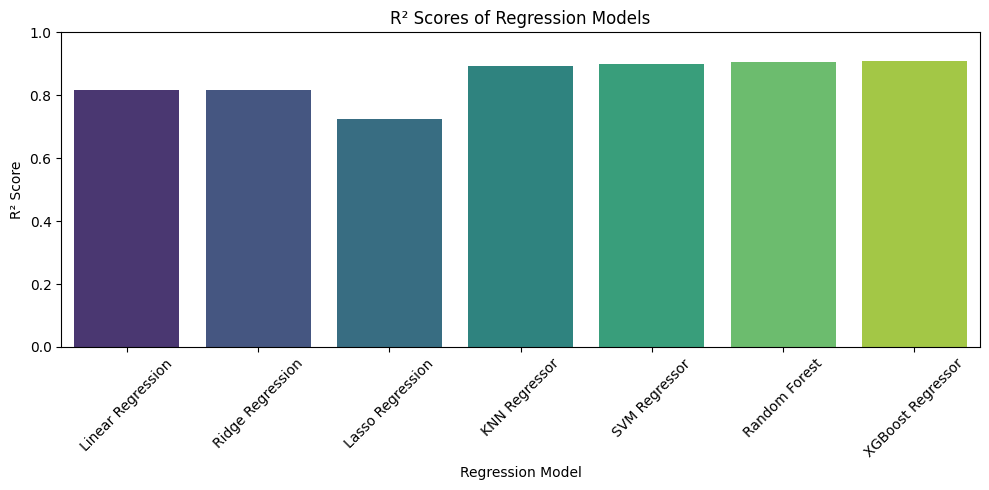

In [20]:
plt.figure(figsize=(10, 5))
sns.barplot(x=list(r2_scores.keys()), y=list(r2_scores.values()), palette='viridis')
plt.title("R² Scores of Regression Models")
plt.ylabel("R² Score")
plt.xlabel("Regression Model")
plt.ylim(0, 1)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()